In [122]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd


# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [123]:
mpl.rcParams['font.size'] = 13  # Slightly increase the base font size
mpl.rcParams['axes.labelsize'] = 14  # Slightly increase axis label size
mpl.rcParams['axes.titlesize'] = 15  # Slightly increase plot title size
mpl.rcParams['legend.fontsize'] = 13  # Slightly increase legend font size
mpl.rcParams['xtick.labelsize'] = 13  # Slightly increase x-tick label size
mpl.rcParams['ytick.labelsize'] = 13  # Slightly increase y-tick label size

In [124]:
# Create Logger object (needed to load data)
logger = Logger()

# Load the pandas dataframe
df = logger.load_log("2024-10-22_14-38-46")

# Print some information about the df
df.shape
df.info()
df.describe()

Loading log files from directory: /media/ahansson/2884-8728/logs/2024-10-22_14-38-46
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242200 entries, 0 to 242199
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   RunID             242200 non-null  int64  
 1   Timestamp         242200 non-null  float64
 2   perturbation_log  200 non-null     object 
 3   gp_GT             242200 non-null  object 
 4   gp_pred           242200 non-null  object 
 5   gp_lower          242200 non-null  object 
 6   gp_upper          242200 non-null  object 
 7   n_points_GP       242200 non-null  int64  
 8   record_time       242200 non-null  float64
 9   solve_time        242200 non-null  float64
 10  tracking_error    242200 non-null  float64
 11  attitude_error    242200 non-null  float64
 12  mpc_cost          242200 non-null  object 
 13  u_demanded        242200 non-null  object 
 14  velocity          242200 non-nu

,RunID,Timestamp,n_points_GP,record_time,solve_time,tracking_error,attitude_error,velocity,e_gp,e_nom
count,242200.000000,242200.000000,242200.000000,242200.000000,242200.000000,242200.000000,242200.000000,242200.000000,2.420000e+05,2.420000e+05
mean,99.500000,60.500000,78.739513,7.963975,37.695689,0.044060,6.705485,0.168301,4.027304e-04,4.141172e-03
std,57.734424,34.958619,75.037297,7.881628,6.953158,0.151517,19.132754,0.055555,1.854333e-03,8.256784e-03
min,0.000000,0.000000,0.000000,0.069458,27.725313,0.000002,0.000246,0.000000,6.306007e-08,5.548627e-09
25%,49.750000,30.200000,27.000000,3.651175,33.429112,0.000897,0.250155,0.152564,1.035215e-05,7.258620e-04
50%,99.500000,60.500000,55.000000,6.578407,35.566512,0.003777,0.685187,0.198760,5.275696e-05,1.686780e-03
75%,149.250000,90.800000,105.000000,8.789741,39.566731,0.014083,2.928893,0.199995,1.505180e-04,4.174329e-03
max,199.000000,121.000000,300.000000,137.231578,163.257041,2.329847,179.993197,0.328356,1.163845e-01,6.931107e-02


In [125]:
# Calculate and print the mean tracking error of all run ids
mean_tracking_error = df.groupby("RunID")["tracking_error"].mean()



In [126]:
# Count how many runs violoate constraints
# Group by 'RunID' and check if any tracking error in that run is larger than 1m
run_ids_with_error_gt_1m = df.groupby('RunID')['tracking_error'].apply(lambda x: (x > 1).any())

# Getting the list of RunIDs where tracking error is larger than 1m
run_ids_with_error_gt_1m = run_ids_with_error_gt_1m[run_ids_with_error_gt_1m].index.tolist()

print(f'RunIDs with tracking error larger than 1m: {run_ids_with_error_gt_1m}')


RunIDs with tracking error larger than 1m: [3, 11, 31, 37, 69, 72, 88, 122, 124, 129, 148, 149, 152, 156, 195]


Colors in the 'science' style: ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']
RunID: 3
Maximum Tracking Error: 1.217113153649257 m
Number of Perturbations: 6
Perturbation Log: [(0, 26.652985382999645, 'stuck_off'), (2, 26.652985382999645, 'stuck_off'), (7, 26.884510457444897, 'stuck_off'), (10, 28.70288176380604, 'faulty_valve (0.01, 0.29)'), (9, 15.21977028185233, 'saturated_thrust'), (1, 21.887902171211163, 'thrust_instability')]

RunID: 11
Maximum Tracking Error: 1.005418935114362 m
Number of Perturbations: 7
Perturbation Log: [(5, 14.982446551443424, 'stuck_off'), (7, 14.982446551443424, 'stuck_off'), (2, 11.30001100052603, 'stuck_off'), (11, 24.108408193597555, 'faulty_valve (0.00, 0.29)'), (8, 28.714176574875523, 'saturated_thrust'), (4, 4.7161752730779805, 'saturated_thrust'), (3, 21.558057742279733, 'thrust_instability')]

RunID: 31
Maximum Tracking Error: 1.068293610268412 m
Number of Perturbations: 6
Perturbation Log: [(4, 4.927212318220979, 'st

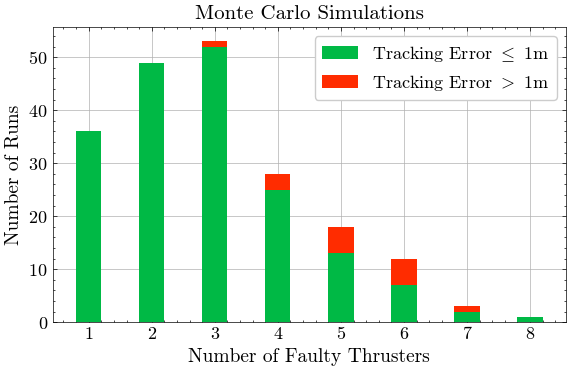

In [127]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
# Get the color cycle in the current style
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Print the first few colors in the cycle
print(f"Colors in the 'science' style: {colors}")

# Assuming 'df' is your DataFrame

# Step 1: Extract maximum tracking error per RunID
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)

# Step 2: Extract perturbation logs at timestamp 0 for each RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]

# Step 3: Merge the two DataFrames
merged_df = pd.merge(max_tracking_error, perturbation_logs, on='RunID', how='left')

# Step 4: Filter runs with tracking error > 1m
high_error_runs = merged_df[merged_df['max_tracking_error'] > 1.0]

# Step 5: Print the perturbation logs for these runs, including the number of perturbations
if high_error_runs.empty:
    print("No runs with tracking error greater than 1 meter.")
else:
    for idx, row in high_error_runs.iterrows():
        perturbation_log = row['perturbation_log']
        
        # Count the number of perturbations
        if perturbation_log is None:
            num_perturbations = 0
        elif isinstance(perturbation_log, float) and np.isnan(perturbation_log):
            num_perturbations = 0
        elif isinstance(perturbation_log, (list, tuple, np.ndarray)):
            num_perturbations = len(perturbation_log)
        elif isinstance(perturbation_log, str):
            try:
                perturbations = ast.literal_eval(perturbation_log)
                num_perturbations = len(perturbations)
            except (ValueError, SyntaxError):
                num_perturbations = 0
        else:
            # Handle unexpected data types
            num_perturbations = 0

        print(f"RunID: {row['RunID']}")
        print(f"Maximum Tracking Error: {row['max_tracking_error']} m")
        print(f"Number of Perturbations: {num_perturbations}")
        print(f"Perturbation Log: {perturbation_log}\n")

# Step 1: Define the function to count unique faulty thrusters (as before)
def count_faulty_thrusters(log):
    if log is None:
        return 0
    if isinstance(log, float) and np.isnan(log):
        return 0
    if isinstance(log, (list, tuple, np.ndarray)):
        if len(log) == 0:
            return 0
        perturbations = log
    elif isinstance(log, str):
        try:
            perturbations = ast.literal_eval(log)
        except (ValueError, SyntaxError):
            return 0
    else:
        # If log is of an unexpected type, return 0
        return 0
    thrusters = set()
    for p in perturbations:
        try:
            thrusters.add(p[0])
        except (IndexError, TypeError):
            continue
    return len(thrusters)

# Step 2: Apply the function to count faulty thrusters
merged_df['num_faulty_thrusters'] = merged_df['perturbation_log'].apply(count_faulty_thrusters)

# Step 3: Categorize runs based on tracking error
merged_df['error_category'] = np.where(merged_df['max_tracking_error'] > 1.0, 'Above 1m', 'Below 1m')

# Step 4: Group data for the histogram
hist_data = merged_df.groupby(['num_faulty_thrusters', 'error_category']).size().unstack(fill_value=0).reset_index()

# Step 4a: Ensure 'Above 1m' and 'Below 1m' columns exist
if 'Above 1m' not in hist_data.columns:
    hist_data['Above 1m'] = 0
if 'Below 1m' not in hist_data.columns:
    hist_data['Below 1m'] = 0

# Convert counts to integers
hist_data[['Above 1m', 'Below 1m']] = hist_data[['Above 1m', 'Below 1m']].astype(int)

# Step 5: Remove x entries where no data is available
# We only keep entries where the total count is greater than zero
hist_data['Total'] = hist_data['Above 1m'] + hist_data['Below 1m']
hist_data = hist_data[hist_data['Total'] > 0]

# Now, proceed to plot the histogram
fig, ax = plt.subplots(figsize=(6, 4))

bar_width = 0.4
index = np.arange(len(hist_data))

# Plot the stacked bars
ax.grid(zorder=0)

# Check if 'Below 1m' data is available
if hist_data['Below 1m'].sum() > 0:
    ax.bar(index, hist_data['Below 1m'], bar_width, label='Tracking Error $\leq$ 1m', color='#00B945', zorder=3)

# Check if 'Above 1m' data is available
if hist_data['Above 1m'].sum() > 0:
    ax.bar(index, hist_data['Above 1m'], bar_width, bottom=hist_data['Below 1m'], label='Tracking Error $>$ 1m', color='#FF2C00', zorder=3)

# Set labels and title
ax.set_xlabel('Number of Faulty Thrusters')
ax.set_ylabel('Number of Runs')
ax.set_title('Monte Carlo Simulations')
ax.set_xticks(index)
ax.set_xticklabels(hist_data['num_faulty_thrusters'].astype(int))
ax.legend(framealpha=1, frameon=True)

plt.tight_layout()

plt.savefig("MC/MC_results.svg", format="svg")
plt.savefig("MC/MC_results.pdf", format="pdf")


plt.show()



In [128]:
import pandas as pd
import numpy as np
import ast
from tabulate import tabulate

# Step 2: Define a function to extract the float value from arrays
def extract_float_from_array(value):
    if isinstance(value, (list, np.ndarray)):
        if len(value) == 1:
            return value[0]
        else:
            # If the array has more than one element, decide how to handle it
            # For example, take the sum, mean, or use np.nan
            return np.nan  # or return sum(value), np.mean(value), etc.
    elif isinstance(value, (int, float, np.number)):
        return value
    elif isinstance(value, str):
        # Try to parse the string as a list or a number
        try:
            parsed_value = ast.literal_eval(value)
            if isinstance(parsed_value, (list, tuple, np.ndarray)):
                if len(parsed_value) == 1:
                    return parsed_value[0]
                else:
                    return np.nan  # Handle as needed
            elif isinstance(parsed_value, (int, float, np.number)):
                return parsed_value
            else:
                return np.nan
        except (ValueError, SyntaxError):
            return np.nan
    else:
        return np.nan

# Step 3: Apply the function to 'mpc_cost' to extract float values
df['mpc_cost'] = df['mpc_cost'].apply(extract_float_from_array)
df['mpc_cost'] = df['mpc_cost'].apply(extract_float_from_array)

# Add the constant to 'mpc_cost'
df['mpc_cost'] += 0.2 * 5e-3  # Equivalent to adding 0.001

# Calculate the cumulative cost per 'RunID'
df['cumulative_cost'] = df.groupby('RunID')['mpc_cost'].cumsum()

# Step 1: Exclude unsuccessful runs (tracking error above 1m)
max_tracking_error = df.groupby('RunID')['tracking_error'].max().reset_index()
max_tracking_error.rename(columns={'tracking_error': 'max_tracking_error'}, inplace=True)
successful_runids = max_tracking_error[max_tracking_error['max_tracking_error'] <= 1.0]['RunID'].unique()
df_successful = df[df['RunID'].isin(successful_runids)].copy()

# Step 2: Define a function to count unique faulty thrusters
def count_faulty_thrusters(log):
    if log is None or (isinstance(log, float) and np.isnan(log)):
        return 0
    try:
        if isinstance(log, str):
            perturbations = ast.literal_eval(log)
        elif isinstance(log, (list, tuple, np.ndarray)):
            perturbations = log
        else:
            return 0
        thrusters = set(p[0] for p in perturbations if isinstance(p, (list, tuple)) and len(p) > 0)
        return len(thrusters)
    except (ValueError, SyntaxError, TypeError):
        return 0

# Step 3: Get 'perturbation_log' at Timestamp == 0.0 per RunID
perturbation_logs = df[df['Timestamp'] == 0.0][['RunID', 'perturbation_log']]
perturbation_logs_successful = perturbation_logs[perturbation_logs['RunID'].isin(successful_runids)].copy()
perturbation_logs_successful['num_faulty_thrusters'] = perturbation_logs_successful['perturbation_log'].apply(count_faulty_thrusters)

# Step 4: Ensure 'e_gp' and 'e_nom' are numeric
df_successful['e_gp'] = pd.to_numeric(df_successful['e_gp'], errors='coerce')
df_successful['e_nom'] = pd.to_numeric(df_successful['e_nom'], errors='coerce')

# Step 5: Ensure 'cumulative_cost' is numeric
df_successful['cumulative_cost'] = pd.to_numeric(df_successful['cumulative_cost'], errors='coerce')

# Step 6: Get the last 'cumulative_cost' per RunID
cumulative_cost_per_run = df_successful.groupby('RunID')['cumulative_cost'].last().reset_index()

# Step 7: Compute run metrics
run_metrics = df_successful.groupby('RunID').agg({
    'tracking_error': 'mean',
    'attitude_error': 'mean',
    'e_gp': 'mean',
    'e_nom': 'mean'
}).reset_index().rename(columns={
    'tracking_error': 'tracking_error_mean',
    'attitude_error': 'attitude_error_mean',
    'e_gp': 'e_gp_mean',
    'e_nom': 'e_nom_mean'
})

# Merge 'cumulative_cost' into 'run_metrics'
run_metrics = run_metrics.merge(cumulative_cost_per_run, on='RunID', how='left')

# Merge 'num_faulty_thrusters' into 'run_metrics'
run_metrics = run_metrics.merge(
    perturbation_logs_successful[['RunID', 'num_faulty_thrusters']],
    on='RunID',
    how='left'
)

# Step 8: Group 'run_metrics' by 'num_faulty_thrusters' and compute the required metrics
table = run_metrics.groupby('num_faulty_thrusters').agg({
    'RunID': 'count',
    'tracking_error_mean': 'mean',
    'attitude_error_mean': 'mean',
    'cumulative_cost': 'mean',
    'e_gp_mean': 'mean',
    'e_nom_mean': 'mean'
}).reset_index().rename(columns={'RunID': 'Number of Runs'})

# Step 9: Convert 'num_faulty_thrusters' to string to include 'Average' row
table['num_faulty_thrusters'] = table['num_faulty_thrusters'].astype(str)

# Step 10: Compute the overall averages (last row)
overall_averages = pd.DataFrame({
    'num_faulty_thrusters': ['Average'],
    'Number of Runs': [run_metrics['RunID'].nunique()],
    'tracking_error_mean': [run_metrics['tracking_error_mean'].mean()],
    'attitude_error_mean': [run_metrics['attitude_error_mean'].mean()],
    'cumulative_cost': [run_metrics['cumulative_cost'].mean()],
    'e_gp_mean': [run_metrics['e_gp_mean'].mean()],
    'e_nom_mean': [run_metrics['e_nom_mean'].mean()]
})

# Step 11: Concatenate 'table' and 'overall_averages'
table = pd.concat([table, overall_averages], ignore_index=True)

# Step 12: Set 'num_faulty_thrusters' as the index
table.set_index('num_faulty_thrusters', inplace=True)

# Step 13: Ensure that numeric columns are of numeric type
numeric_cols = [
    'Number of Runs',
    'tracking_error_mean',
    'attitude_error_mean',
    'cumulative_cost',
    'e_gp_mean',
    'e_nom_mean'
]
for col in numeric_cols:
    table[col] = pd.to_numeric(table[col], errors='coerce')

# Step 14: Round numerical columns for better readability
table_rounded = table.copy()
table_rounded[numeric_cols] = table_rounded[numeric_cols].round(6)

# Step 15: Display the table in a pretty format
print(tabulate(table_rounded.reset_index(), headers='keys', tablefmt='psql'))

# Step 16: Export the table to LaTeX
latex_table = table.to_latex(float_format="%.6f", index=True)
print(latex_table)


+----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------+
|    | num_faulty_thrusters   |   Number of Runs |   tracking_error_mean |   attitude_error_mean |   cumulative_cost |   e_gp_mean |   e_nom_mean |
|----+------------------------+------------------+-----------------------+-----------------------+-------------------+-------------+--------------|
|  0 | 1                      |               36 |              0.014012 |               2.019   |          0.686868 |    8.8e-05  |     0.001243 |
|  1 | 2                      |               49 |              0.017097 |               2.70575 |          0.922647 |    0.000184 |     0.002126 |
|  2 | 3                      |               52 |              0.016899 |               3.06406 |          0.944828 |    0.000254 |     0.002783 |
|  3 | 4                      |               25 |              0.029736 |               5.84993 |          1.60

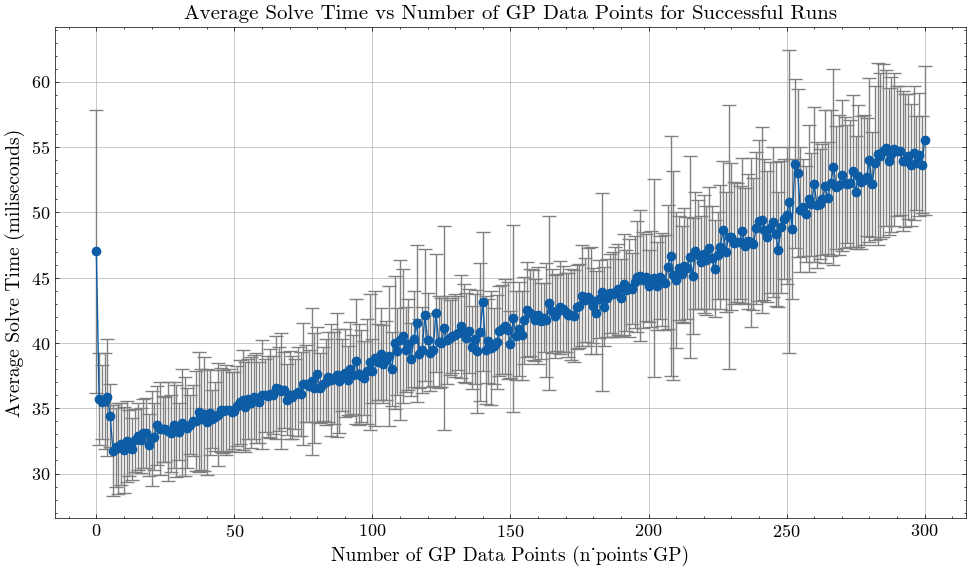

In [129]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'solve_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['solve_time'] = pd.to_numeric(df_successful['solve_time'], errors='coerce')

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'solve_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'solve_time'])

# Step 3: Compute mean and standard deviation of 'solve_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['solve_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'solve_time' with standard deviation error bars
plt.figure(figsize=(10, 6))

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1  # Marker edge width
)

plt.xlabel('Number of GP Data Points (n_points_GP)')
plt.ylabel('Average Solve Time (miliseconds)')
plt.title('Average Solve Time vs Number of GP Data Points for Successful Runs')
plt.grid(True)
plt.tight_layout()
plt.show()


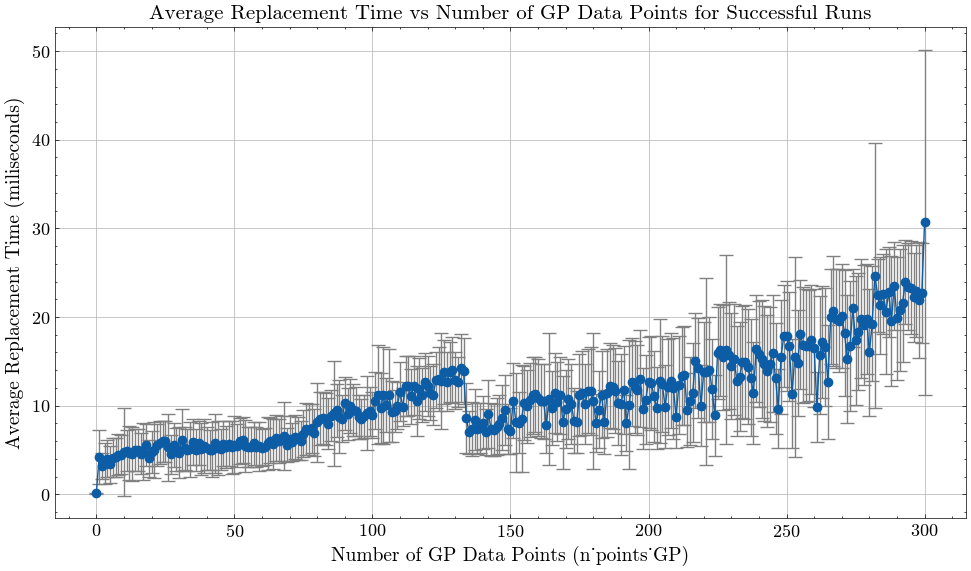

In [130]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'record_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['record_time'] = pd.to_numeric(df_successful['record_time'], errors='coerce')

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'record_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'record_time'])

# Step 3: Compute mean and standard deviation of 'record_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['record_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'record_time' with standard deviation error bars
plt.figure(figsize=(10, 6))

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1  # Marker edge width
)

plt.xlabel('Number of GP Data Points (n_points_GP)')
plt.ylabel('Average Replacement Time (miliseconds)')
plt.title('Average Replacement Time vs Number of GP Data Points for Successful Runs')
plt.grid(True)
plt.tight_layout()
plt.show()


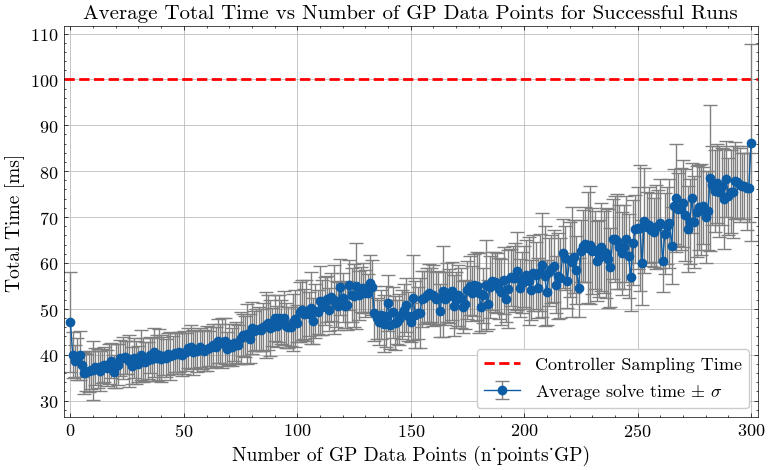

In [134]:
# Assuming 'df' is your DataFrame and 'df_successful' contains successful runs as defined earlier.

# Step 1: Ensure 'n_points_GP' and 'record_time' are numeric
df_successful['n_points_GP'] = pd.to_numeric(df_successful['n_points_GP'], errors='coerce')
df_successful['solve_time'] = pd.to_numeric(df_successful['solve_time'], errors='coerce')
df_successful['record_time'] = pd.to_numeric(df_successful['record_time'], errors='coerce')
df_successful['total_time'] = df_successful['solve_time'] + df_successful['record_time']

# Step 2: Remove any rows with NaN values in 'n_points_GP' or 'total_time'
df_successful_clean = df_successful.dropna(subset=['n_points_GP', 'total_time'])

# Step 3: Compute mean and standard deviation of 'total_time' per 'n_points_GP'
n_points_gp_stats = df_successful_clean.groupby('n_points_GP')['total_time'].agg(['mean', 'std', 'count']).reset_index()

# Step 4: Plot 'n_points_GP' vs average 'total_time' with standard deviation error bars
plt.figure(figsize=(8, 5))

# Add the red dashed horizontal line at 1m for Constraint Violation
plt.axhline(y=100, color='red', linestyle='--', label='Controller Sampling Time', linewidth=2)

# Plot with error bars
plt.errorbar(
    n_points_gp_stats['n_points_GP'],
    n_points_gp_stats['mean'],
    yerr=n_points_gp_stats['std'],
    fmt='o-',  # Format line with circle markers
    capsize=5,  # Adds caps to the error bars
    ecolor='gray',  # Error bar color
    elinewidth=1,  # Error bar line width
    markeredgewidth=1,  # Marker edge width
    label = 'Average solve time $\pm$ $\sigma$'
)



plt.xlabel('Number of GP Data Points (n_points_GP)')
plt.ylabel('Total Time [ms]')
plt.title('Average Total Time vs Number of GP Data Points for Successful Runs')
plt.xlim((-3,303))
plt.grid(True)
plt.legend(loc='best', facecolor='white', framealpha=1, frameon=True)
plt.tight_layout()

plt.savefig("MC/MC_solve_total.svg", format="svg")
plt.savefig("MC/MC_solve_total.pdf", format="pdf")

plt.show()
